In [5]:
import pandas as pd
import mysql.connector

In [6]:
# 2. Load dataset
df = pd.read_csv("hotel_bookings.csv")

print(df.shape)
df.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03/07/2015


In [7]:
# 3. Clean and prepare data
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df_clean = df.rename(columns={
    "arrival_date_year": "arrival_year",
    "arrival_date_month": "arrival_month",
    "arrival_date_week_number": "arrival_week",
    "arrival_date_day_of_month": "arrival_day",
    "stays_in_weekend_nights": "stays_weekend",
    "stays_in_week_nights": "stays_weekday"
})

df_clean = df_clean[
    [
        "hotel",
        "is_canceled",
        "lead_time",
        "arrival_year",
        "arrival_month",
        "arrival_week",
        "arrival_day",
        "stays_weekend",
        "stays_weekday",
        "total_guests",
        "meal",
        "country",
        "market_segment",
        "adr",
        "deposit_type",
        "customer_type",
        "reservation_status"
    ]
]

print(df_clean.shape)
df_clean.head()

(119390, 17)


,hotel,is_canceled,lead_time,arrival_year,arrival_month,arrival_week,arrival_day,stays_weekend,stays_weekday,total_guests,meal,country,market_segment,adr,deposit_type,customer_type,reservation_status
0,Resort Hotel,0,342,2015,July,27,1,0,0,2.0,BB,PRT,Direct,0.0,No Deposit,Transient,Check-Out
1,Resort Hotel,0,737,2015,July,27,1,0,0,2.0,BB,PRT,Direct,0.0,No Deposit,Transient,Check-Out
2,Resort Hotel,0,7,2015,July,27,1,0,1,1.0,BB,GBR,Direct,75.0,No Deposit,Transient,Check-Out
3,Resort Hotel,0,13,2015,July,27,1,0,1,1.0,BB,GBR,Corporate,75.0,No Deposit,Transient,Check-Out
4,Resort Hotel,0,14,2015,July,27,1,0,2,2.0,BB,GBR,Online TA,98.0,No Deposit,Transient,Check-Out


In [8]:
# 4. Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="SRashid7572277$",
    database="travelpulse_db"
)

cursor = conn.cursor()

print("Connected to MySQL successfully")

Connected to MySQL successfully


In [9]:
insert_query = """
INSERT INTO bookings (
    hotel, is_canceled, lead_time, arrival_year, arrival_month,
    arrival_week, arrival_day, stays_weekend, stays_weekday,
    total_guests, meal, country, market_segment, adr,
    deposit_type, customer_type, reservation_status
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

data = [tuple(row) for row in df_clean.to_numpy()]

cursor.executemany(insert_query, data)
conn.commit()

print("Inserted rows:", cursor.rowcount)

Inserted rows: 119390


In [10]:
#verify
cursor.execute("SELECT COUNT(*) FROM bookings")
print(cursor.fetchone())

(119390,)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

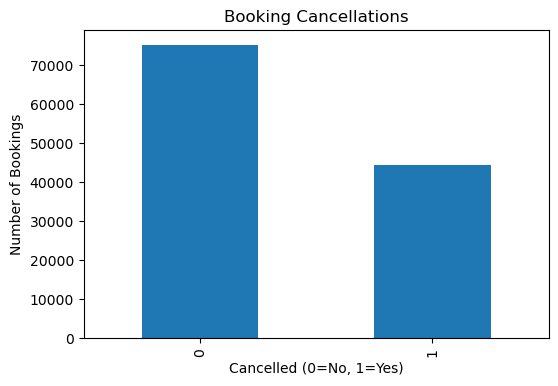

In [13]:
cancel_counts = df_clean["is_canceled"].value_counts()

plt.figure(figsize=(6,4))
cancel_counts.plot(kind="bar")
plt.title("Booking Cancellations")
plt.xlabel("Cancelled (0=No, 1=Yes)")
plt.ylabel("Number of Bookings")
plt.show()

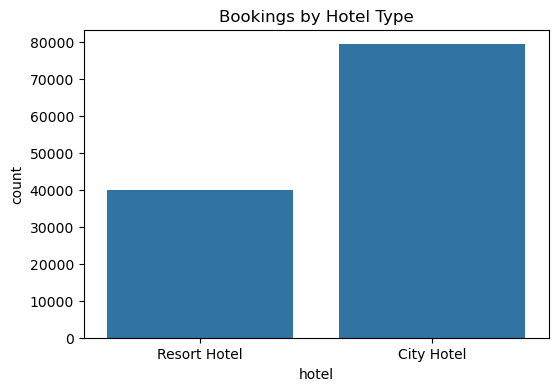

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="hotel",
    data=df_clean
)

plt.title("Bookings by Hotel Type")
plt.show()

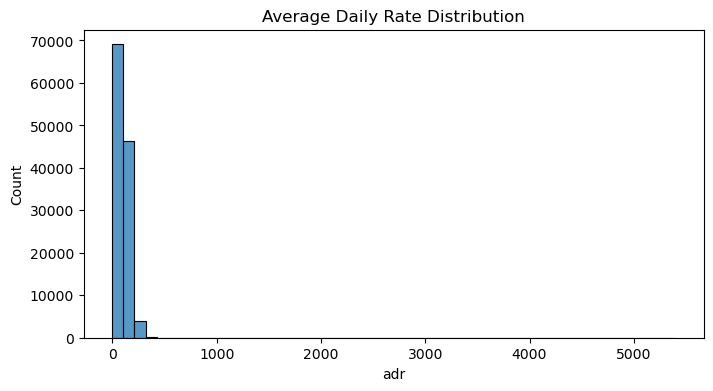

In [15]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_clean["adr"],
    bins=50
)

plt.title("Average Daily Rate Distribution")
plt.show()

In [18]:
df_clean.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_week', 'arrival_day', 'stays_weekend', 'stays_weekday',
       'total_guests', 'meal', 'country', 'market_segment', 'adr',
       'deposit_type', 'customer_type', 'reservation_status'],
      dtype='object')

In [19]:
df_clean[[
    "lead_time",
    "total_guests",
    "adr",
    "stays_weekend",
    "stays_weekday",
    "hotel",
    "deposit_type",
    "customer_type",
    "is_canceled"
]].head()

,lead_time,total_guests,adr,stays_weekend,stays_weekday,hotel,deposit_type,customer_type,is_canceled
0,342,2.0,0.0,0,0,Resort Hotel,No Deposit,Transient,0
1,737,2.0,0.0,0,0,Resort Hotel,No Deposit,Transient,0
2,7,1.0,75.0,0,1,Resort Hotel,No Deposit,Transient,0
3,13,1.0,75.0,0,1,Resort Hotel,No Deposit,Transient,0
4,14,2.0,98.0,0,2,Resort Hotel,No Deposit,Transient,0


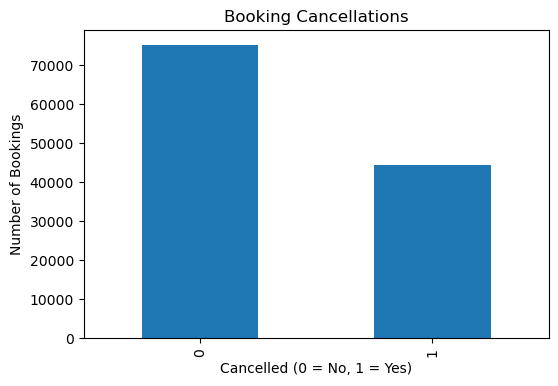

In [20]:
import matplotlib.pyplot as plt

cancel_counts = df_clean["is_canceled"].value_counts()

plt.figure(figsize=(6,4))
cancel_counts.plot(kind="bar")

plt.title("Booking Cancellations")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")

plt.show()

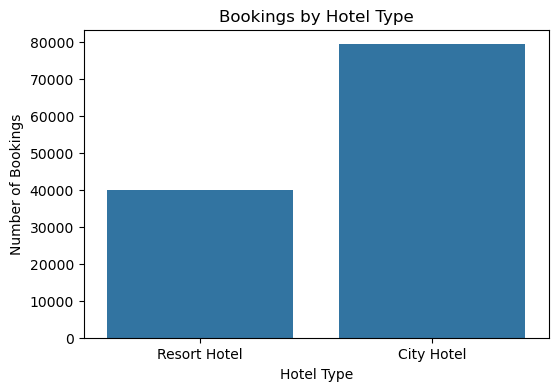

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="hotel",
    data=df_clean
)

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

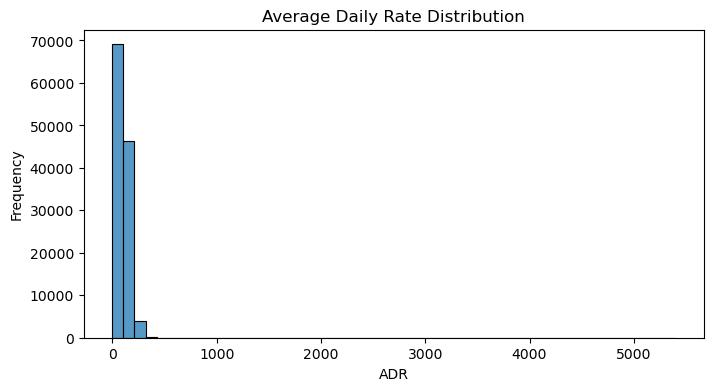

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_clean["adr"],
    bins=50
)

plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

In [23]:
cancel_rate = df_clean["is_canceled"].mean() * 100
print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancellation Rate: 37.04%


In [24]:
print("Average ADR:", round(df_clean["adr"].mean(),2))

Average ADR: 101.83


In [25]:
df_clean["country"].value_counts().head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [32]:
ml_df = df_clean.copy()

categorical_cols = [
    "hotel",
    "deposit_type",
    "customer_type"
]

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])

X = ml_df[
    [
        "lead_time",
        "total_guests",
        "adr",
        "stays_weekend",
        "stays_weekday",
        "hotel",
        "deposit_type",
        "customer_type"
    ]
]

y = ml_df["is_canceled"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 79.87 %


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84     14907
           1       0.77      0.67      0.71      8971

    accuracy                           0.80     23878
   macro avg       0.79      0.77      0.78     23878
weighted avg       0.80      0.80      0.80     23878



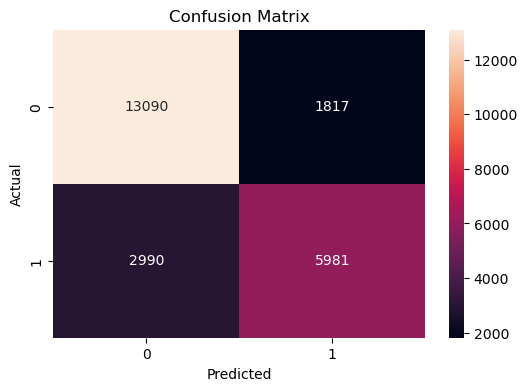

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
0      lead_time    0.347760
2            adr    0.321737
6   deposit_type    0.183056
4  stays_weekday    0.054870
7  customer_type    0.029668
3  stays_weekend    0.026560
1   total_guests    0.023467
5          hotel    0.012883


In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
0      lead_time    0.347760
2            adr    0.321737
6   deposit_type    0.183056
4  stays_weekday    0.054870
7  customer_type    0.029668
3  stays_weekend    0.026560
1   total_guests    0.023467
5          hotel    0.012883


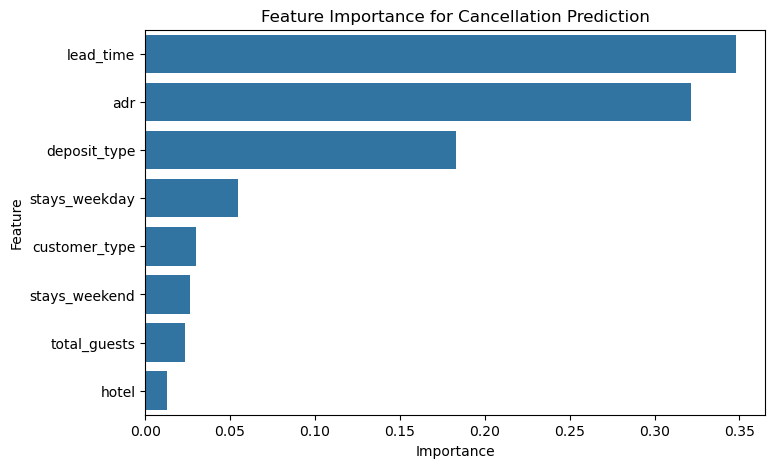

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance for Cancellation Prediction")
plt.show()

In [38]:
df_clean.to_csv("cleaned_hotel_bookings.csv", index=False)

In [39]:
monthly_demand = (
    df_clean.groupby(["arrival_year", "arrival_month"])
    .size()
    .reset_index(name="bookings")
)

monthly_demand.head()

,arrival_year,arrival_month,bookings
0,2015,August,3889
1,2015,December,2920
2,2015,July,2776
3,2015,November,2340
4,2015,October,4957


In [40]:
month_order = {
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
}

monthly_demand["month_num"] = monthly_demand["arrival_month"].map(month_order)

In [41]:
monthly_demand = monthly_demand.sort_values(
    ["arrival_year", "month_num"]
)

monthly_demand["time_index"] = range(
    1,
    len(monthly_demand) + 1
)

monthly_demand.head()

,arrival_year,arrival_month,bookings,month_num,time_index
2,2015,July,2776,7,1
0,2015,August,3889,8,2
5,2015,September,5114,9,3
4,2015,October,4957,10,4
3,2015,November,2340,11,5


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

X = monthly_demand[["time_index"]]
y = monthly_demand["bookings"]

lr_model = LinearRegression()

lr_model.fit(X, y)

predictions = lr_model.predict(X)

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

r2 = r2_score(y, predictions)
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

print("R²:", round(r2,3))
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

R²: 0.272
MAE: 798.79
RMSE: 933.09


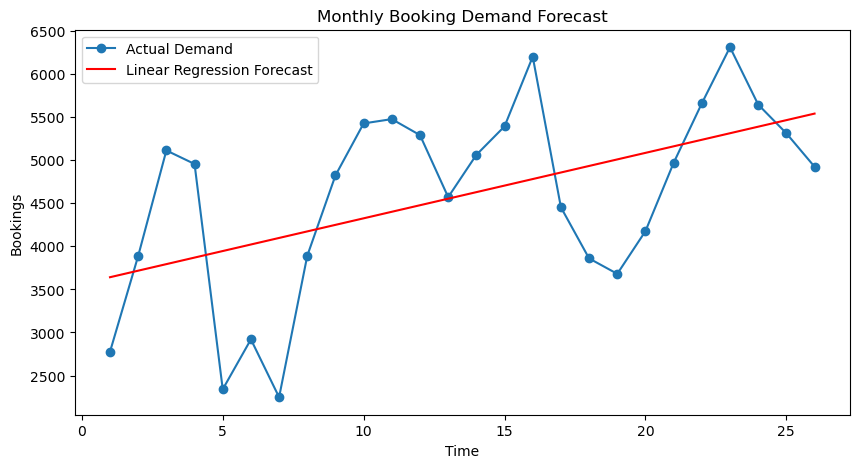

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_demand["time_index"],
    y,
    marker="o",
    label="Actual Demand"
)

plt.plot(
    monthly_demand["time_index"],
    predictions,
    color="red",
    label="Linear Regression Forecast"
)

plt.title("Monthly Booking Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Bookings")

plt.legend()

plt.show()

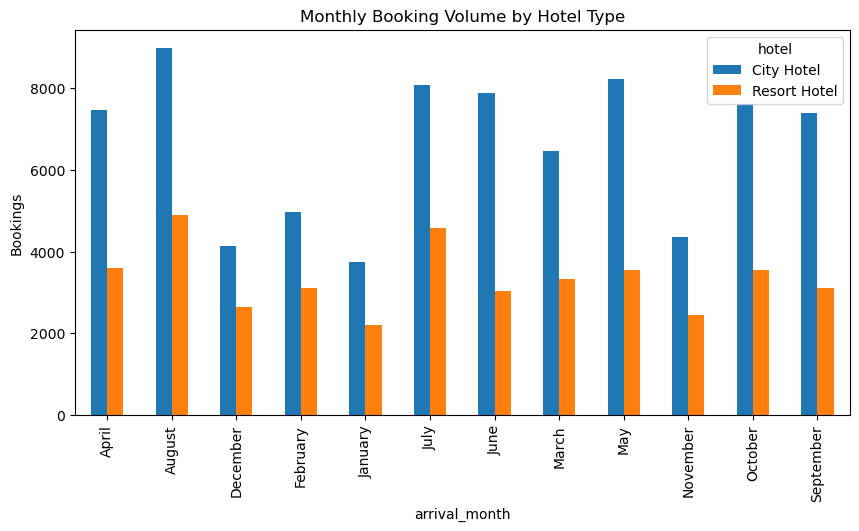

In [45]:
monthly_hotel = df_clean.groupby(
    ["arrival_month","hotel"]
).size().unstack()

monthly_hotel.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Booking Volume by Hotel Type")
plt.ylabel("Bookings")
plt.show()

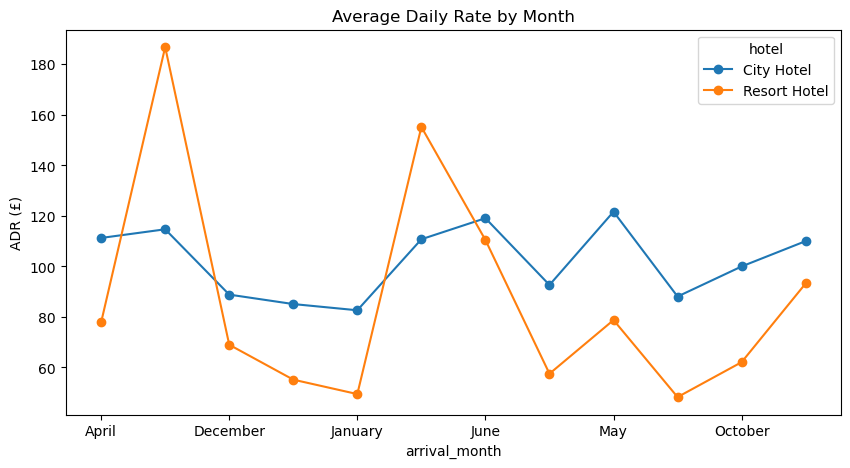

In [46]:
adr_month = df_clean.groupby(
    ["arrival_month","hotel"]
)["adr"].mean().unstack()

adr_month.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Average Daily Rate by Month")
plt.ylabel("ADR (£)")
plt.show()

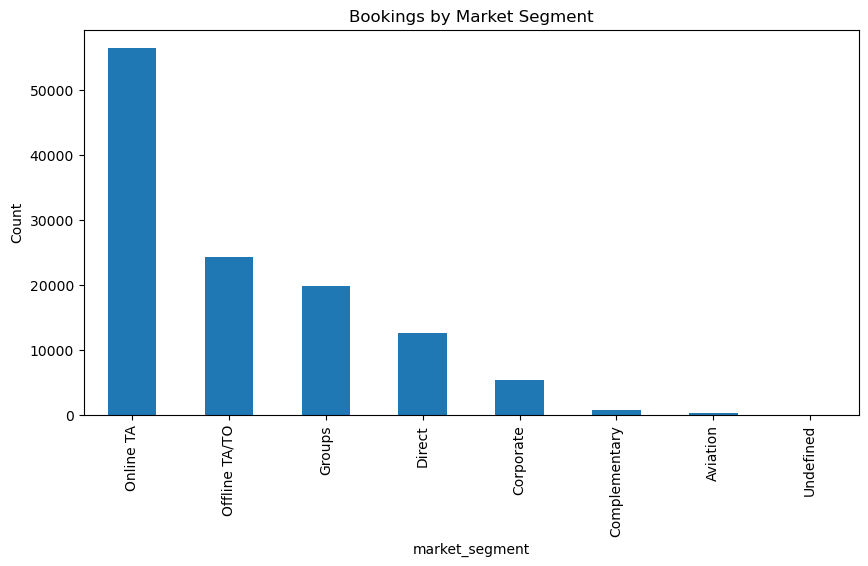

In [47]:
df_clean["market_segment"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Bookings by Market Segment")
plt.ylabel("Count")
plt.show()

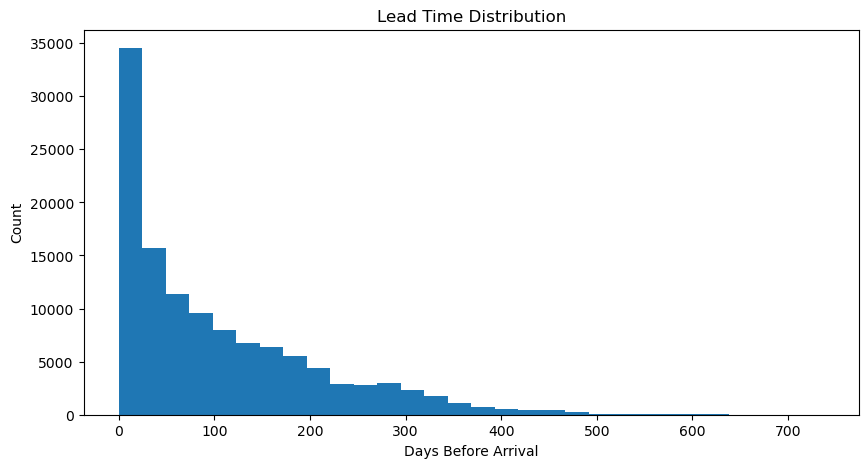

In [48]:
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["lead_time"],
    bins=30
)

plt.title("Lead Time Distribution")
plt.xlabel("Days Before Arrival")
plt.ylabel("Count")

plt.show()

In [2]:
df.isnull().sum()


NameError: name 'df' is not defined